# Classificação de Tumores de Mama: Regressão Logística vs Random Forest

**Objetivo:** classificar tumores de mama como **malignos** ou **benignos** a partir de medidas extraídas de imagens de exames.

**Diferença em relação a um problema de regressão:** aqui o modelo não prevê um número contínuo, mas uma **classe**. Isso muda as métricas: não basta medir o quanto o modelo acerta no geral, é preciso olhar **que tipo de erro** ele comete.

**Por que o tipo de erro importa:** classificar um tumor maligno como benigno (falso negativo) é muito mais grave do que o contrário, porque o paciente pode ficar sem tratamento.

**Etapas:**
1. Carregamento e entendimento dos dados
2. Análise exploratória
3. Separação entre treino e teste
4. Regressão Logística
5. Random Forest Classifier
6. Comparação das métricas
7. Conclusões

**Tecnologias:** Python, pandas, scikit-learn, matplotlib, seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report,
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Carregando os dados

O dataset **Breast Cancer Wisconsin** tem 569 exames. Para cada um, foram calculadas 30 medidas dos núcleos das células na imagem, como raio, textura, perímetro, área e suavidade.

No dataset original, o alvo vale **0 para maligno** e **1 para benigno**. Inverto para **1 = maligno**, porque é a classe que queremos detectar. Assim, as métricas de "classe positiva" passam a se referir aos tumores malignos.

In [2]:
dados = load_breast_cancer(as_frame=True)
X = dados.data
y = 1 - dados.target  # 1 = maligno, 0 = benigno

print(f"Exames: {X.shape[0]} | Variáveis: {X.shape[1]}")
print(f"Valores ausentes: {X.isna().sum().sum()}")
X.head()

Exames: 569 | Variáveis: 30
Valores ausentes: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Análise exploratória

target
Benigno    357
Maligno    212
Name: count, dtype: int64

target
Benigno    0.627
Maligno    0.373
Name: count, dtype: float64


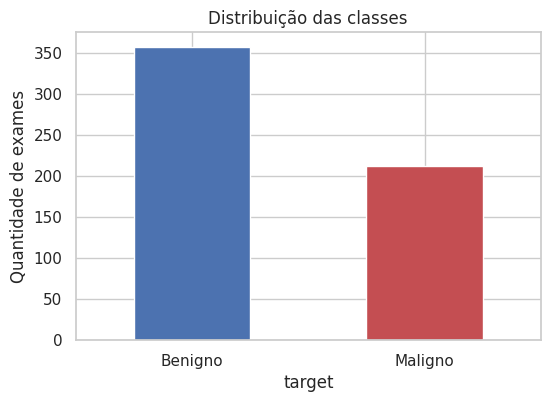

In [3]:
contagem = y.map({1: "Maligno", 0: "Benigno"}).value_counts()
print(contagem)
print()
print((contagem / len(y)).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
contagem.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Distribuição das classes")
ax.set_ylabel("Quantidade de exames")
plt.xticks(rotation=0)
plt.show()

As classes estão **desbalanceadas**: há mais tumores benignos que malignos. Isso tem duas consequências:

- A **acurácia** sozinha engana. Um modelo que chutasse "benigno" sempre acertaria cerca de 63% dos casos sem aprender nada.
- Na separação entre treino e teste, é preciso manter a mesma proporção de classes nos dois conjuntos (**estratificação**).

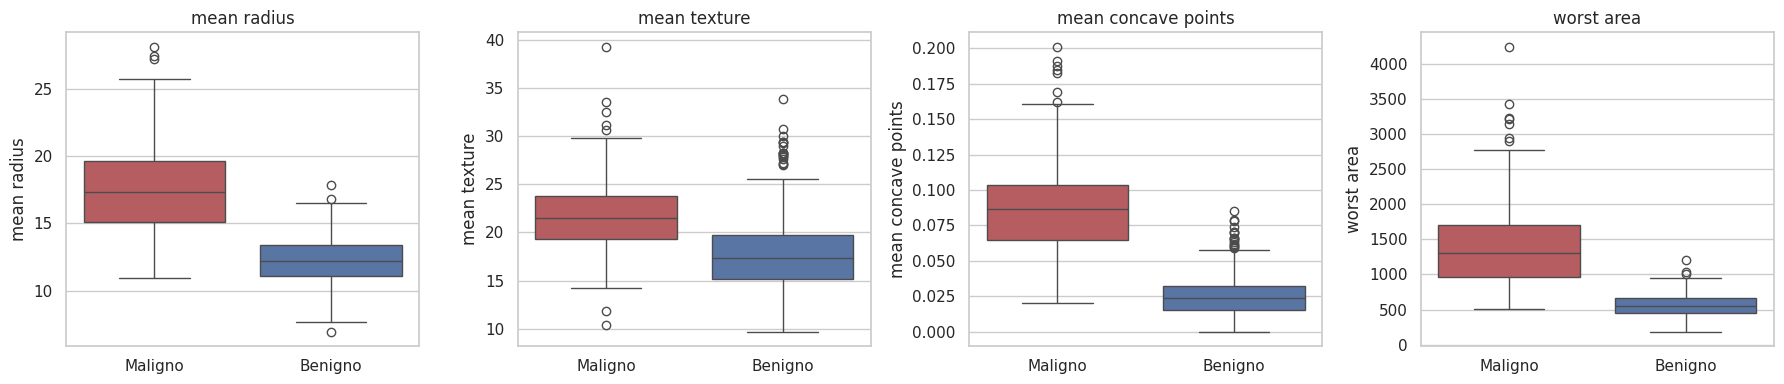

In [4]:
variaveis = ["mean radius", "mean texture", "mean concave points", "worst area"]
rotulo = y.map({1: "Maligno", 0: "Benigno"})

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, var in zip(axes, variaveis):
    sns.boxplot(x=rotulo, y=X[var], ax=ax, hue=rotulo, legend=False,
                palette={"Benigno": "#4C72B0", "Maligno": "#C44E52"})
    ax.set_title(var)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

Tumores malignos tendem a ter células maiores (raio e área) e com contornos mais irregulares (pontos côncavos). Quando as distribuições das duas classes se sobrepõem pouco, a variável separa bem as classes.

## 3. Separação entre treino e teste

Uso `stratify=y` para garantir que treino e teste tenham a mesma proporção de tumores malignos.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {len(X_train)} exames ({y_train.mean():.1%} malignos)")
print(f"Teste:  {len(X_test)} exames ({y_test.mean():.1%} malignos)")

Treino: 455 exames (37.4% malignos)
Teste:  114 exames (36.8% malignos)


## 4. Métricas de avaliação

| Métrica | Pergunta que responde |
|---|---|
| **Acurácia** | De todos os exames, quantos o modelo classificou certo? |
| **Precisão** | Dos exames que o modelo disse que são malignos, quantos realmente são? |
| **Recall (sensibilidade)** | Dos tumores realmente malignos, quantos o modelo encontrou? |
| **F1** | Média harmônica entre precisão e recall. Equilibra as duas. |
| **ROC AUC** | Capacidade do modelo de separar as classes, considerando todos os limiares de decisão. 1 é perfeito, 0,5 é aleatório. |

**Neste problema, o recall é a métrica mais importante**, porque cada ponto perdido nela é um tumor maligno que passou despercebido.

In [6]:
def avaliar(nome, modelo, X, y):
    """Calcula as principais métricas de classificação de um modelo treinado."""
    pred = modelo.predict(X)
    prob = modelo.predict_proba(X)[:, 1]
    return {
        "Modelo": nome,
        "Acurácia": accuracy_score(y, pred),
        "Precisão": precision_score(y, pred),
        "Recall": recall_score(y, pred),
        "F1": f1_score(y, pred),
        "ROC AUC": roc_auc_score(y, prob),
    }

resultados = []

## 5. Regressão Logística

Apesar do nome, a Regressão Logística é um modelo de **classificação**. Ela calcula uma soma ponderada das variáveis, como a Regressão Linear, e passa o resultado pela **função sigmoide**, que transforma qualquer número em uma probabilidade entre 0 e 1:

$$P(\text{maligno}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n)}}$$

Se a probabilidade passar de 0,5, o modelo classifica como maligno.

Uso `StandardScaler` no pipeline porque a Regressão Logística usa regularização por padrão, que é sensível à escala das variáveis.

In [7]:
modelo_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
modelo_lr.fit(X_train, y_train)

resultados.append(avaliar("Regressão Logística", modelo_lr, X_test, y_test))
pd.DataFrame(resultados).round(3)

,Modelo,Acurácia,Precisão,Recall,F1,ROC AUC
0,Regressão Logística,0.965,0.975,0.929,0.951,0.996


## 6. Random Forest Classifier

Funciona como o Random Forest de regressão, mas cada árvore **vota em uma classe**, e a previsão final é a classe mais votada. A proporção de votos funciona como a probabilidade.

In [8]:
modelo_rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

resultados.append(avaliar("Random Forest", modelo_rf, X_test, y_test))
pd.DataFrame(resultados).round(3)

,Modelo,Acurácia,Precisão,Recall,F1,ROC AUC
0,Regressão Logística,0.965,0.975,0.929,0.951,0.996
1,Random Forest,0.965,1.000,0.905,0.950,0.994


## 7. Matriz de confusão

A matriz de confusão mostra exatamente onde cada modelo errou:

|  | Previsto benigno | Previsto maligno |
|---|---|---|
| **Real benigno** | Verdadeiro negativo | Falso positivo |
| **Real maligno** | **Falso negativo** (o erro mais grave) | Verdadeiro positivo |

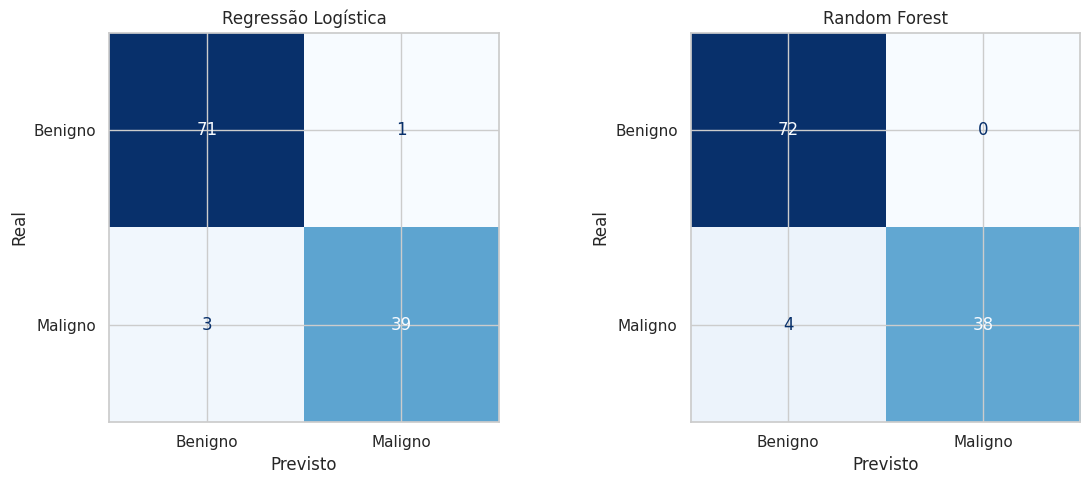

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (nome, modelo) in zip(axes, [("Regressão Logística", modelo_lr), ("Random Forest", modelo_rf)]):
    ConfusionMatrixDisplay.from_estimator(
        modelo, X_test, y_test, display_labels=["Benigno", "Maligno"],
        cmap="Blues", colorbar=False, ax=ax,
    )
    ax.set_title(nome)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

In [10]:
for nome, modelo in [("Regressão Logística", modelo_lr), ("Random Forest", modelo_rf)]:
    print(f"=== {nome} ===")
    print(classification_report(y_test, modelo.predict(X_test),
                                target_names=["Benigno", "Maligno"], digits=3))

=== Regressão Logística ===
              precision    recall  f1-score   support

     Benigno      0.959     0.986     0.973        72
     Maligno      0.975     0.929     0.951        42

    accuracy                          0.965       114
   macro avg      0.967     0.957     0.962       114
weighted avg      0.965     0.965     0.965       114

=== Random Forest ===
              precision    recall  f1-score   support

     Benigno      0.947     1.000     0.973        72
     Maligno      1.000     0.905     0.950        42

    accuracy                          0.965       114
   macro avg      0.974     0.952     0.961       114
weighted avg      0.967     0.965     0.965       114



## 8. Curva ROC

A curva ROC mostra o equilíbrio entre encontrar tumores malignos (taxa de verdadeiros positivos) e dar alarmes falsos (taxa de falsos positivos) para todos os limiares de decisão possíveis. Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo.

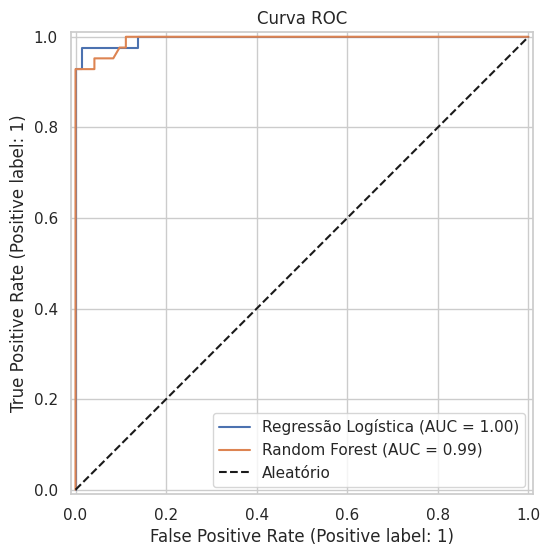

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
for nome, modelo in [("Regressão Logística", modelo_lr), ("Random Forest", modelo_rf)]:
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, name=nome, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Aleatório")
ax.set_title("Curva ROC")
ax.legend()
plt.show()

## 9. Validação cruzada

Com apenas 114 exames no teste, cada erro muda bastante as métricas. A validação cruzada estratificada com 5 folds dá uma estimativa mais confiável.

In [12]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

linhas_cv = []
for nome, modelo in [("Regressão Logística", modelo_lr), ("Random Forest", modelo_rf)]:
    recall_cv = cross_val_score(modelo, X_train, y_train, cv=kfold, scoring="recall")
    f1_cv = cross_val_score(modelo, X_train, y_train, cv=kfold, scoring="f1")
    linhas_cv.append({
        "Modelo": nome,
        "Recall médio": recall_cv.mean(),
        "Recall desvio": recall_cv.std(),
        "F1 médio": f1_cv.mean(),
        "F1 desvio": f1_cv.std(),
    })

pd.DataFrame(linhas_cv).round(3)

,Modelo,Recall médio,Recall desvio,F1 médio,F1 desvio
0,Regressão Logística,0.953,0.040,0.964,0.021
1,Random Forest,0.935,0.039,0.949,0.021


## 10. Variáveis mais relevantes

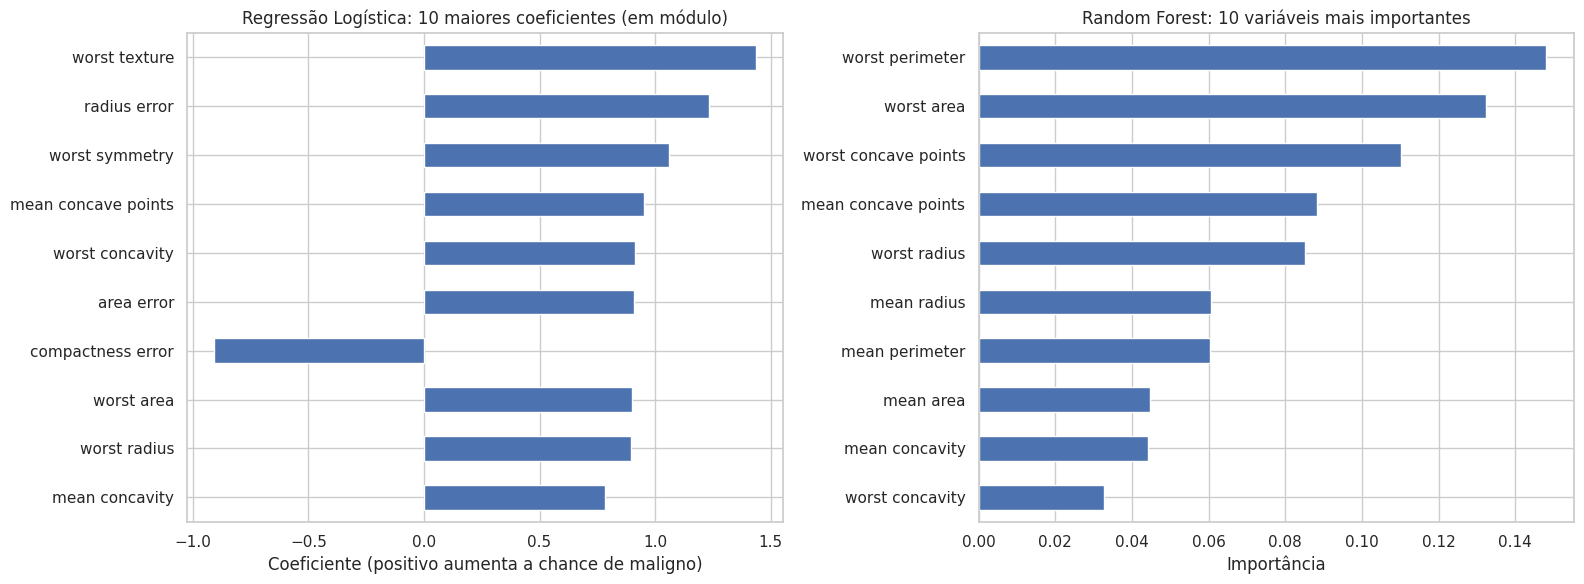

In [13]:
coefs = pd.Series(modelo_lr.named_steps["logisticregression"].coef_[0], index=X.columns)
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

coefs.reindex(coefs.abs().sort_values().index[-10:]).plot(kind="barh", ax=axes[0])
axes[0].set_title("Regressão Logística: 10 maiores coeficientes (em módulo)")
axes[0].set_xlabel("Coeficiente (positivo aumenta a chance de maligno)")

importancias.sort_values().tail(10).plot(kind="barh", ax=axes[1])
axes[1].set_title("Random Forest: 10 variáveis mais importantes")
axes[1].set_xlabel("Importância")

plt.tight_layout()
plt.show()

## 11. Comparação final

In [14]:
tabela = pd.DataFrame(resultados).set_index("Modelo").round(3)
tabela

,Acurácia,Precisão,Recall,F1,ROC AUC
Modelo,,,,,
Regressão Logística,0.965,0.975,0.929,0.951,0.996
Random Forest,0.965,1.000,0.905,0.950,0.994


## 12. Conclusões

<!-- Revise estas conclusões com base nos seus resultados -->

- Os dois modelos têm desempenho alto, porque as medidas das células separam bem as classes.
- A acurácia não é suficiente para comparar os modelos. A decisão deve considerar principalmente o **recall** e a quantidade de **falsos negativos** na matriz de confusão.
- A Regressão Logística é mais simples e interpretável: o sinal do coeficiente indica se a variável aumenta ou diminui a chance de o tumor ser maligno.

## 13. Próximos passos

- Ajustar o limiar de decisão (hoje em 0,5) para aumentar o recall, aceitando mais falsos positivos
- Ajustar hiperparâmetros com `GridSearchCV`
- Testar outros modelos, como SVM e gradient boosting

**Observação:** este é um projeto de estudo com um dataset público e não substitui diagnóstico médico.